
# Lab1_3: PDE

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define the base URL for your GitHub repository's raw content
# IMPORTANT: Replace 'YOUR_GITHUB_USERNAME/YOUR_REPO_NAME/main' with your actual GitHub username, repository name, and branch.
# For example: 'your_user/your_repo/main'
github_base_url = 'https://raw.githubusercontent.com/YOUR_GITHUB_USERNAME/YOUR_REPO_NAME/main/'

# Define the sub-path to your figures folder within the repository
figures_sub_path = 'Fisica_Computacional_1/figures/'

# Combine the base URL and sub-path to get the full path to your figures
path = github_base_url + figures_sub_path

# Define the filenames
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'



#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

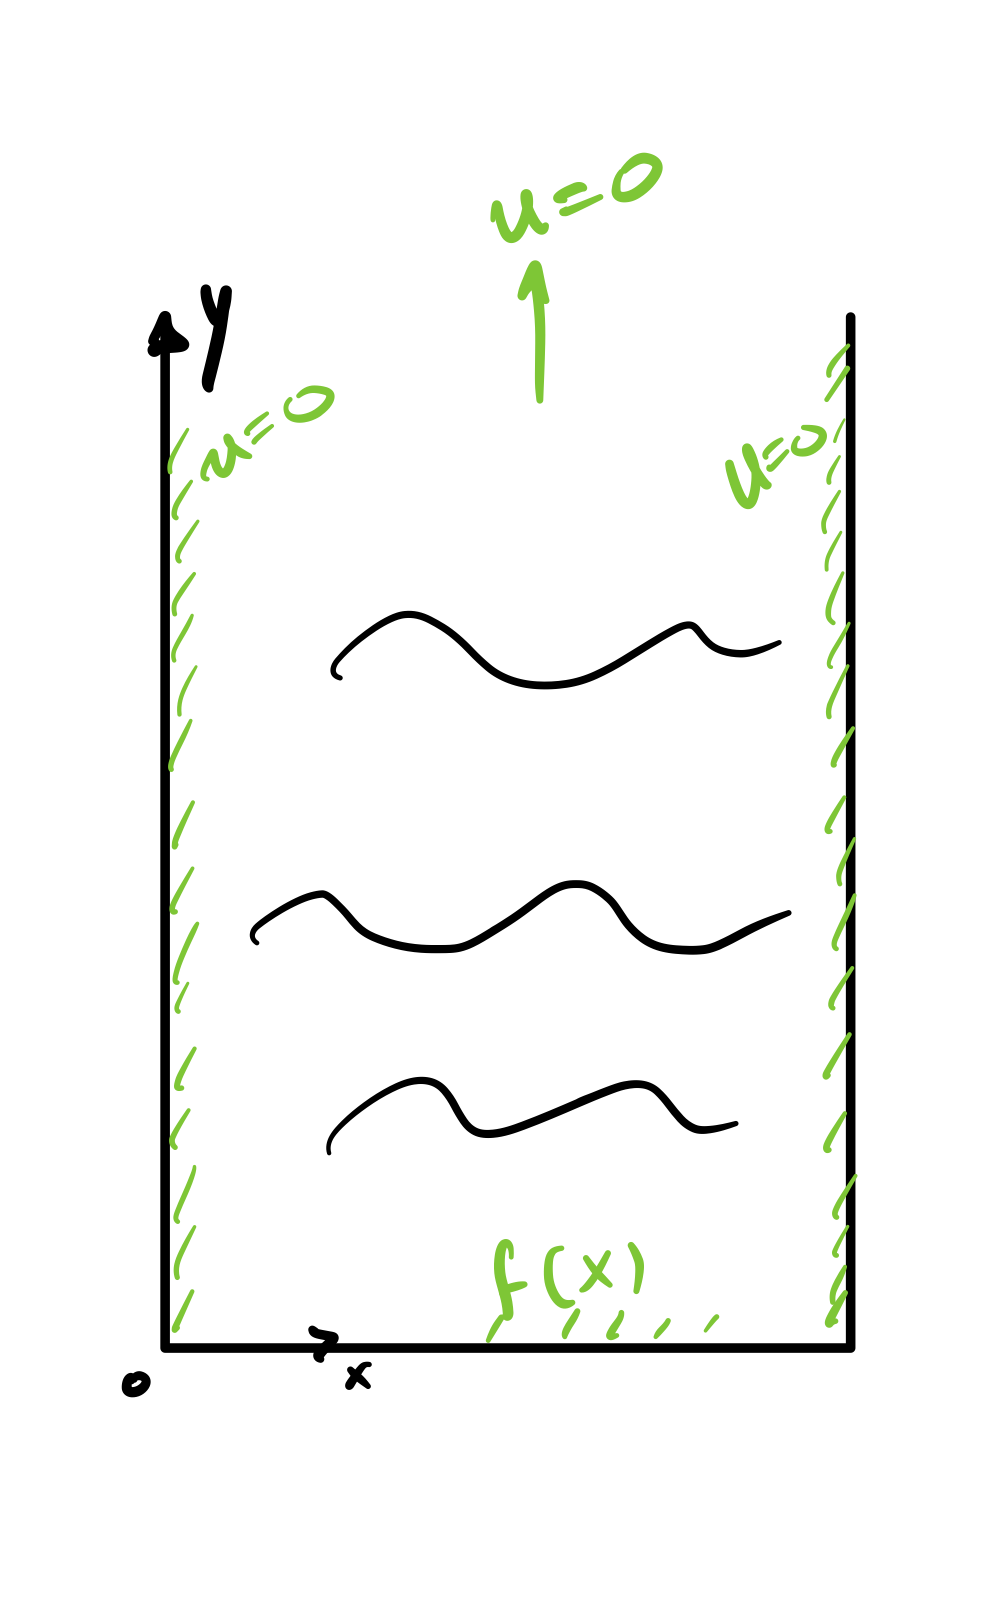

In [ ]:
from IPython.display import Image
Image(filename=path+filename4, width=300)

In [77]:
import pandas as pd
import numpy as np
import sympy as spy
import matplotlib.pyplot as plt


Método de diferencias finitas
Buscando mejor ajuste .... Iteración 1000 , error =2e-02
Método de diferencias finitas
Buscando mejor ajuste .... Iteración 2000 , error =5e-03
Método de diferencias finitas
Buscando mejor ajuste .... Iteración 3000 , error =2e-03
Comienza la  solución anlítica
Se necesitó 50 términos para la precisión deseada


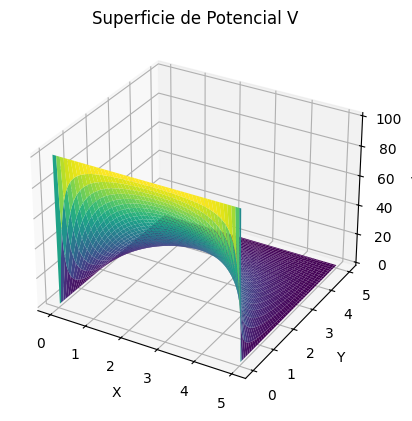

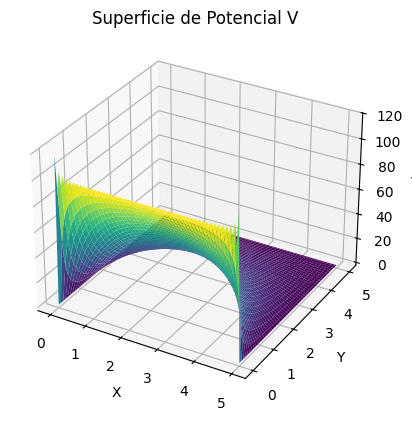

[[1.00000000e+02 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [1.00000000e+02 4.99877793e+01 3.02102952e+01 ... 2.03594643e-02
  1.01738615e-02 0.00000000e+00]
 [1.00000000e+02 6.97408264e+01 4.99511259e+01 ... 4.06993863e-02
  2.03379601e-02 0.00000000e+00]
 ...
 [1.00000000e+02 6.97409253e+01 4.99513236e+01 ... 4.08822572e-02
  2.04293948e-02 0.00000000e+00]
 [1.00000000e+02 4.99878299e+01 3.02103962e+01 ... 2.04528789e-02
  1.02205684e-02 0.00000000e+00]
 [1.00000000e+02 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]


In [78]:
N   = 100
l , tope = 0, 20000
tolerancia ,error = 1e-3 ,1
V_0 = 100
L=5   # L diferente de 1 porque si no hay problemas en la fórmula teórica


#**************************************************************************
def fourier_teorico(x,y,V_0,n,L):
    C_n= 4*V_0/(n*np.pi*np.sinh(n*np.pi))
    return C_n * np.sin( n * np.pi * x/L ) * np.sinh( n * np.pi * (L-y)/L)

#***************************************************************************


# Creamos los arrays x e y para las dimensiones de la matriz V

x = np.linspace(0, L, N)   # N puntos, incluidos 0 y L
y = np.linspace(0, L, N)

# Usamos np.meshgrid para crear las matrices 2D de coordenadas X e Y
# que la función plot_surface espera.
X, Y = np.meshgrid(x, y, indexing='ij')




V = np.zeros((N,N))

# Condición de frontera inferior
for k in range(0,N):
    V[k,0] = V_0

#se va a partir inicialmente de la primera malla para el potencial V donde
# los bordes , los  puntos interiores  son cero y la parte inferior de la placa tienen un valor de 100
# pero esta malla de valores de V se modifica en la primera iteracion , los bordes sigen siendo 100 para
# el inferior y cero para los demás bordes pero los puntos interiores ya no son cero! y esta malla modificada
# será el punto de partida para la siguiente iteración

while l < tope and error > tolerancia :
    V_old = V.copy()
    for i in range(1,N-1):
        for j in range(1,N-1):
            V[i,j]=0.25*(V[i+1,j]+V[i-1,j]+V[i,j+1]+V[i,j-1])
    l+=1
    error= np.max(np.abs(V-V_old))

    #condicion para mostrar el progreso cada 1000 iteraciones
    if l%1000 == 0:
        print('Método de diferencias finitas')
        print(f'Buscando mejor ajuste .... Iteración {l} , error ={error:.0e}')




print('Comienza la  solución anlítica')

l=0
n=1
error = 1

V_temp=np.zeros_like(X,dtype=float)

while l < tope and error > tolerancia :

    V_old = V_temp.copy()
    V_temp += fourier_teorico(X,Y,V_0,n,L)
    error= np.max(np.abs(V_temp - V_old))
    l+=1
    n += 2


print(f'Se necesitó {l} términos para la precisión deseada' )




#*************************************************
#********* comienza la parte de Graficos**********
#*************************************************
#*************************************************




# Para gráficos 3D, necesitamos importar Axes3D de mpl_toolkits.mplot3d
from mpl_toolkits.mplot3d import Axes3D

# Creamos una figura y un eje con proyección 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Ahora podemos usar plot_surface en el eje 3D (ax)
ax.plot_surface(X, Y, V, cmap='viridis') # 'viridis' es un buen mapa de colores por defecto
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('V')
ax.set_title('Superficie de Potencial V')
plt.show()






# Creamos una figura y un eje con proyección 3D
fig2 = plt.figure()
ax2 = fig2.add_subplot(111, projection='3d')

# Ahora podemos usar plot_surface en el eje 3D (ax)
ax2.plot_surface(X, Y, V_temp, cmap='viridis') # 'viridis' es un buen mapa de colores por defecto
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('V')
ax2.set_title('Superficie de Potencial V')
plt.show()






Resolviendo Laplace con frontera abierta (numérico)...
Iteración 1000, cambio = 3.25e-03
Convergió en 1427 iteraciones, cambio final = 9.99e-04


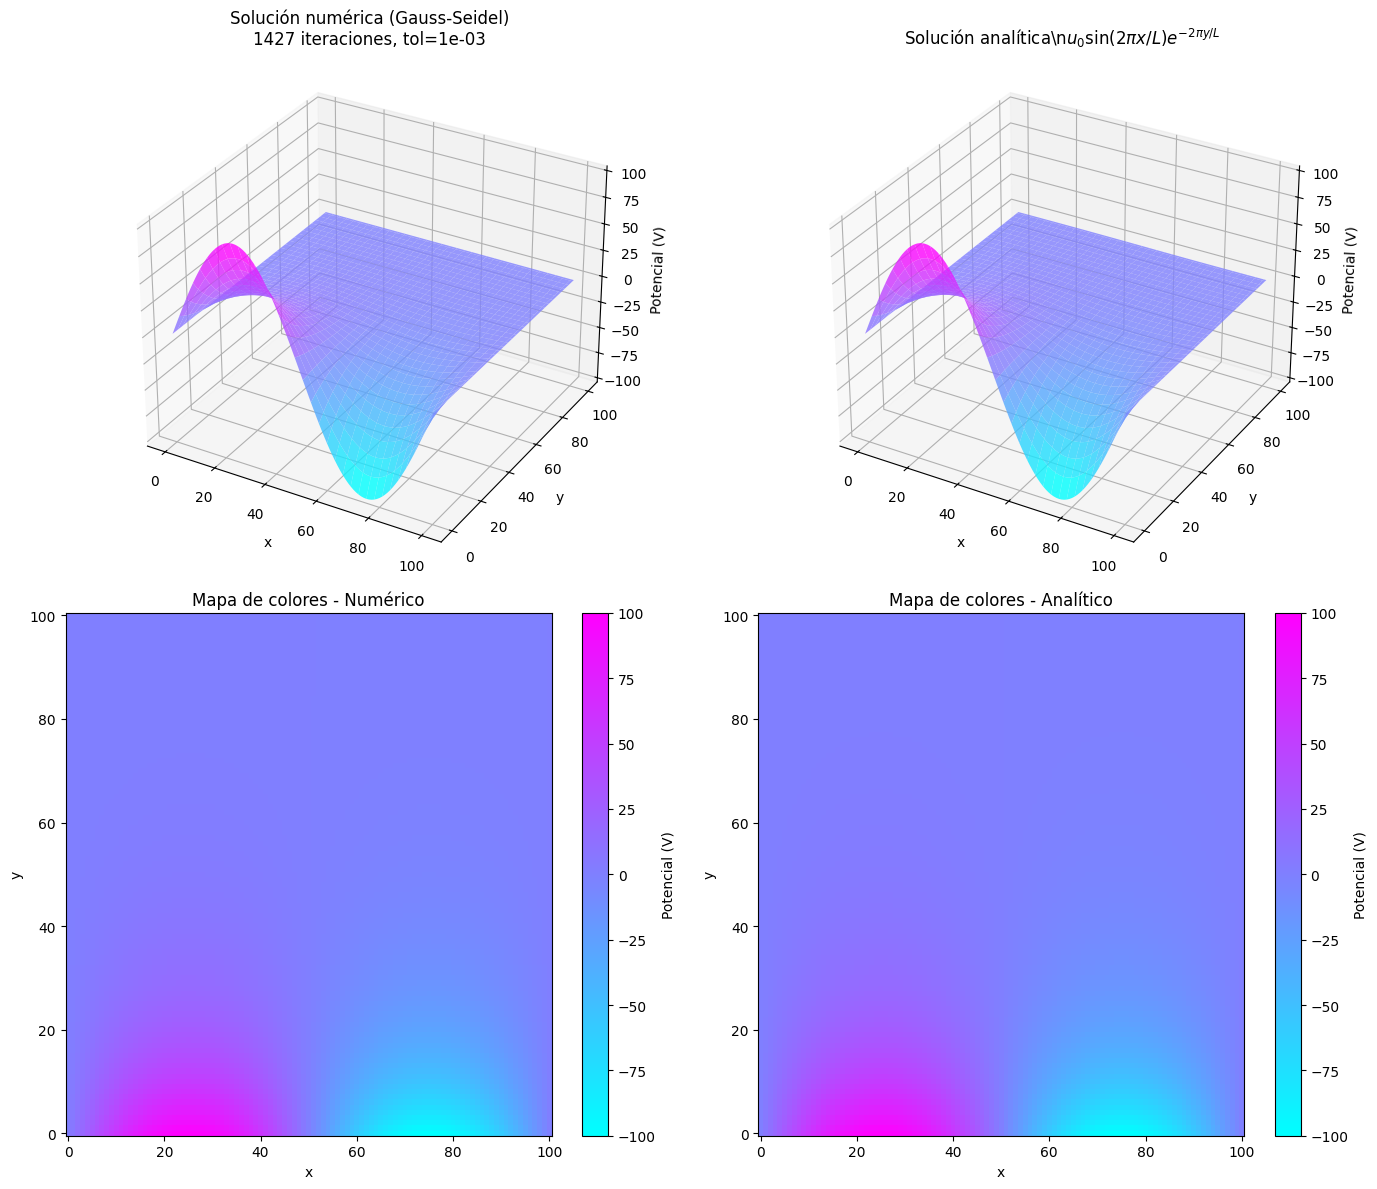

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# Parámetros del problema
# ------------------------------------------------------------
L = 100.0          # longitud en x (y también truncamos y hasta L)
u0 = 100.0         # amplitud del seno
N = 100            # número de divisiones (puntos = N+1)
dx = L / N
dy = dx            # espaciado igual en ambas direcciones
tol = 1e-3         # tolerancia
max_iter = 50000   # seguridad

# Extensión en y (dominio truncado)
Ymax = L           # suficiente porque la solución decae como e^{-2π y/L}
Ny = int(Ymax / dy)   # = N

# ------------------------------------------------------------
# Crear malla de coordenadas físicas
# ------------------------------------------------------------
x = np.linspace(0, L, N+1)
y = np.linspace(0, Ymax, Ny+1)
X, Y = np.meshgrid(x, y, indexing='ij')   # forma (N+1, Ny+1)

# ------------------------------------------------------------
# Solución analítica (exacta)
# ------------------------------------------------------------
u_analitica = u0 * np.sin(2 * np.pi * X / L) * np.exp(-2 * np.pi * Y / L)

# ------------------------------------------------------------
# Solución numérica
# ------------------------------------------------------------
# Inicializar matriz de potencial
u = np.zeros((N+1, Ny+1))

# Condición de contorno inferior (y=0)
u[:, 0] = u0 * np.sin(2 * np.pi * x / L)
# Bordes laterales ya están a cero (inicialización)
# Borde superior (j = Ny) ya está a cero

cambio = 1.0
iteracion = 0
print("Resolviendo Laplace con frontera abierta (numérico)...")
while cambio > tol and iteracion < max_iter:
    u_old = u.copy()
    # Actualizar puntos interiores (i=1..N-1, j=1..Ny-1)
    for i in range(1, N):
        for j in range(1, Ny):
            u[i, j] = 0.25 * (u[i+1, j] + u[i-1, j] + u[i, j+1] + u[i, j-1])
    cambio = np.max(np.abs(u - u_old))
    iteracion += 1
    if iteracion % 1000 == 0:
        print(f'Iteración {iteracion}, cambio = {cambio:.2e}')
print(f'Convergió en {iteracion} iteraciones, cambio final = {cambio:.2e}')

# ------------------------------------------------------------
# Graficar: 4 subplots (2x2)
# ------------------------------------------------------------
fig = plt.figure(figsize=(14, 12))

# 1. Superficie numérica 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X, Y, u, cmap='cool', alpha=0.8)
ax1.set_title(f'Solución numérica (Gauss-Seidel)\n{iteracion} iteraciones, tol={tol:.0e}')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('Potencial (V)')

# 2. Superficie analítica 3D
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot_surface(X, Y, u_analitica, cmap='cool', alpha=0.8)
ax2.set_title(r'Solución analítica\n$u_0 \sin(2\pi x/L) e^{-2\pi y/L}$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('Potencial (V)')

# 3. Mapa de colores numérico
ax3 = fig.add_subplot(2, 2, 3)
im3 = ax3.pcolormesh(X, Y, u, shading='auto', cmap='cool')
ax3.set_title('Mapa de colores - Numérico')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
fig.colorbar(im3, ax=ax3, label='Potencial (V)')

# 4. Mapa de colores analítico
ax4 = fig.add_subplot(2, 2, 4)
im4 = ax4.pcolormesh(X, Y, u_analitica, shading='auto', cmap='cool')
ax4.set_title('Mapa de colores - Analítico')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
fig.colorbar(im4, ax=ax4, label='Potencial (V)')

plt.tight_layout()
plt.show()